In [19]:
import importlib
from pathlib import Path

import pandas as pd
from IPython.display import display

import movie_recommender.data as movie_data

importlib.reload(movie_data)

build_movie_report = movie_data.build_movie_report
build_catalog_eda_frames = movie_data.build_catalog_eda_frames
build_user_eda_frames = movie_data.build_user_eda_frames
build_user_report = movie_data.build_user_report
prepare_movielens_frames = movie_data.prepare_movielens_frames
search_movies = movie_data.search_movies

DATA_DIR = Path("../movies-database")

movies        = pd.read_csv(DATA_DIR / "movies.csv")
ratings       = pd.read_csv(DATA_DIR / "ratings.csv")
tags          = pd.read_csv(DATA_DIR / "tags.csv")
links         = pd.read_csv(DATA_DIR / "links.csv")
genome_scores = pd.read_csv(DATA_DIR / "genome-scores.csv")
genome_tags   = pd.read_csv(DATA_DIR / "genome-tags.csv")

print("movies:       ", movies.shape)
print("ratings:      ", ratings.shape)
print("tags:         ", tags.shape)
print("links:        ", links.shape)
print("genome_scores:", genome_scores.shape)
print("genome_tags:  ", genome_tags.shape)

movies:        (62423, 3)
ratings:       (25000095, 4)
tags:          (1093360, 4)
links:         (62423, 3)
genome_scores: (15584448, 3)
genome_tags:   (1128, 2)


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# Training spine  (25 M rows, stays lean)
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# Only merge the lightweight metadata you actually need per-rating.
# Keep genome completely out of this frame.
train = (
    ratings[["userId", "movieId", "rating", "timestamp"]]
    .merge(movies[["movieId", "genres"]], on="movieId", how="left")
)

# User-mean-centered rating — critical for many CF models (SVD, ALS, NCF).
user_mean = train.groupby("userId")["rating"].transform("mean")
train["rating_norm"] = (train["rating"] - user_mean).astype("float32")

# Lightweight datetime features for temporal models.
train["year_rated"]  = pd.to_datetime(train["timestamp"], unit="s").dt.year
train["month_rated"] = pd.to_datetime(train["timestamp"], unit="s").dt.month

print(train.shape)          # (25_000_095, 7)
print(train.dtypes)

(25000095, 8)
userId           int64
movieId          int64
rating         float64
timestamp        int64
genres          object
rating_norm    float32
year_rated       int32
month_rated      int32
dtype: object


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# Genre one-hot  (62 K × 19 cols)
# ─────────────────────────────────────────────────────────────────────────────
genre_dummies = (
    movies.set_index("movieId")["genres"]
    .str.get_dummies("|")
    .drop(columns=["(no genres listed)"], errors="ignore")
    .add_prefix("genre_")
    .astype("int8")           # saves memory vs int64
)
print(genre_dummies.shape)  # (62_423, 19)

(62423, 19)


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# Genome: pivot to WIDE once (13 816 × 1 128 ≈ 120 MB in float32)
#           Store as a separate lookup — never join to ratings.
# ─────────────────────────────────────────────────────────────────────────────
tag_id_to_name = genome_tags.set_index("tagId")["tag"]

genome_wide = (
    genome_scores
    .pivot(index="movieId", columns="tagId", values="relevance")
    .astype("float32")
)
genome_wide.columns = [tag_id_to_name.get(t, str(t)) for t in genome_wide.columns]

print(genome_wide.shape)    # (13_816, 1_128)

(13816, 1128)


## Train / Test Split
**Temporal split** is mandatory for recommenders — random split leaks future ratings into training.
Strategy: globally sort by timestamp, hold out the last 20 % as test.
All three models (SVD, MF, NCF) share the same split so results are comparable.

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# Temporal split — 80 % train / 20 % test (by timestamp, NOT random)
# ─────────────────────────────────────────────────────────────────────────────
cutoff_ts = train["timestamp"].quantile(0.80)

df_train = train[train["timestamp"] <= cutoff_ts].copy()
df_test  = train[train["timestamp"] >  cutoff_ts].copy()

# Drop cold-start rows from test: users/movies never seen during training.
# Baseline models can't predict for unseen IDs — handle cold-start separately later.
known_users  = set(df_train["userId"])
known_movies = set(df_train["movieId"])
df_test = df_test[
    df_test["userId"].isin(known_users) &
    df_test["movieId"].isin(known_movies)
].copy()

print(f"Train : {len(df_train):>10,}  rows  ({len(df_train)/len(train):.1%})")
print(f"Test  : {len(df_test):>10,}  rows  ({len(df_test)/len(train):.1%})")
print(f"Dropped from test (cold-start): {len(train[train['timestamp'] > cutoff_ts]) - len(df_test):,}")


Train : 20,000,076  rows  (80.0%)
Test  :    610,664  rows  (2.4%)
Dropped from test (cold-start): 4,389,355


## Integer Encoding & Sparse Matrix
Both sparse-matrix methods (SVD, MF) and embedding layers (NCF) require contiguous
0-based integer indices. Build the lookup dicts from the **training set only** so
test never leaks new IDs into the vocabulary.

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# Integer encoding — fit on training set only
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
from scipy.sparse import csr_matrix

user_ids  = np.sort(df_train["userId"].unique())
movie_ids = np.sort(df_train["movieId"].unique())

user_to_idx  = {uid: i for i, uid in enumerate(user_ids)}
movie_to_idx = {mid: i for i, mid in enumerate(movie_ids)}

N_USERS  = len(user_to_idx)
N_MOVIES = len(movie_to_idx)

for df in [df_train, df_test]:
    df["user_idx"]  = df["userId"].map(user_to_idx).astype("int32")
    df["movie_idx"] = df["movieId"].map(movie_to_idx).astype("int32")

print(f"N_USERS={N_USERS:,}   N_MOVIES={N_MOVIES:,}")

# ─────────────────────────────────────────────────────────────────────────────
# Sparse user-item matrix (for SVD and MF baseline)
# rating_norm is user-mean-centred: 0 = unobserved, near-0 = average preference.
# ─────────────────────────────────────────────────────────────────────────────
R_train = csr_matrix(
    (df_train["rating_norm"].values,
     (df_train["user_idx"].values, df_train["movie_idx"].values)),
    shape=(N_USERS, N_MOVIES),
    dtype="float32",
)

user_mean_map = df_train.groupby("user_idx")["rating"].mean()

print(f"Sparse matrix: {R_train.shape}")
print(f"  nnz        : {R_train.nnz:,}")
print(f"  density    : {R_train.nnz / (N_USERS * N_MOVIES):.4%}")


N_USERS=137,883   N_MOVIES=34,461
Sparse matrix: (137883, 34461)
  nnz        : 20,000,076
  density    : 0.4209%


## Model 1 — SVD Baseline
`scipy.sparse.linalg.svds` decomposes the sparse rating matrix directly — no training loop,
no hyperparameters beyond *k*. Fast first baseline to beat.

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# SVD baseline
# ─────────────────────────────────────────────────────────────────────────────
from scipy.sparse.linalg import svds

K_SVD = 50  # latent factors; try 20, 50, 100

U, sigma, Vt = svds(R_train, k=K_SVD)
# svds returns singular values ascending — flip to descending
U, sigma, Vt = U[:, ::-1], sigma[::-1], Vt[::-1, :]

def predict_svd(u_idx, m_idx):
    """Vectorised prediction without materialising the full N x M matrix."""
    return (U[u_idx] * sigma * Vt[:, m_idx].T).sum(axis=1)

preds_norm = predict_svd(df_test["user_idx"].values, df_test["movie_idx"].values)
preds_svd  = np.clip(preds_norm + df_test["user_idx"].map(user_mean_map).values, 0.5, 5.0)

true_ratings = df_test["rating"].values
rmse_svd = np.sqrt(np.mean((preds_svd - true_ratings) ** 2))
mae_svd  = np.mean(np.abs(preds_svd - true_ratings))
print(f"SVD (k={K_SVD})  RMSE={rmse_svd:.4f}  MAE={mae_svd:.4f}")


SVD (k=50)  RMSE=0.9663  MAE=0.7203


## Models 2 & 3 — Matrix Factorisation and Neural CF (PyTorch)
Both architectures are trained sequentially with identical hyperparameters and the same data loaders, so their results are directly comparable.
- **MF (GMF)** — embedding dot-product + per-user/movie bias; neural analogue of classic ALS.
- **NCF** — GMF path *and* an MLP path, fused before the output layer (He et al. 2017).

> **Scale tip:** 25 M rows is large for a CPU training loop. Use `SAMPLE_FRAC=0.10` first
> to verify the pipeline end-to-end, then set it to `1.0` or move to a GPU.

In [26]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# ── Dataset ───────────────────────────────────────────────────────────────────
class RatingsDataset(Dataset):
    def __init__(self, df):
        self.u = torch.tensor(df["user_idx"].values,  dtype=torch.long)
        self.m = torch.tensor(df["movie_idx"].values, dtype=torch.long)
        self.r = torch.tensor(df["rating"].values,    dtype=torch.float32)
    def __len__(self):          return len(self.r)
    def __getitem__(self, i):   return self.u[i], self.m[i], self.r[i]


# ── Model 2: Matrix Factorisation ─────────────────────────────────────────────
class MatrixFactorisation(nn.Module):
    """rating ≈ dot(user_emb, movie_emb) + bias_user + bias_movie"""
    def __init__(self, n_users, n_movies, n_factors=64):
        super().__init__()
        self.user_emb   = nn.Embedding(n_users,  n_factors)
        self.movie_emb  = nn.Embedding(n_movies, n_factors)
        self.user_bias  = nn.Embedding(n_users,  1)
        self.movie_bias = nn.Embedding(n_movies, 1)
        nn.init.normal_(self.user_emb.weight,  std=0.01)
        nn.init.normal_(self.movie_emb.weight, std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.movie_bias.weight)

    def forward(self, u, m):
        dot  = (self.user_emb(u) * self.movie_emb(m)).sum(dim=1)
        bias = self.user_bias(u).squeeze(1) + self.movie_bias(m).squeeze(1)
        return dot + bias


# ── Model 3: Neural CF (GMF + MLP) ────────────────────────────────────────────
class NeuralCF(nn.Module):
    """He et al. (2017): two separate embedding spaces fused before output."""
    def __init__(self, n_users, n_movies,
                 n_factors_gmf=32, n_factors_mlp=32,
                 mlp_hidden=(128, 64, 32)):
        super().__init__()
        self.u_gmf = nn.Embedding(n_users,  n_factors_gmf)
        self.m_gmf = nn.Embedding(n_movies, n_factors_gmf)
        self.u_mlp = nn.Embedding(n_users,  n_factors_mlp)
        self.m_mlp = nn.Embedding(n_movies, n_factors_mlp)
        dims = [2 * n_factors_mlp, *mlp_hidden]
        self.mlp = nn.Sequential(*[
            layer
            for in_d, out_d in zip(dims, dims[1:])
            for layer in (nn.Linear(in_d, out_d), nn.ReLU())
        ])
        self.output_layer = nn.Linear(n_factors_gmf + mlp_hidden[-1], 1)
        for emb in (self.u_gmf, self.m_gmf, self.u_mlp, self.m_mlp):
            nn.init.normal_(emb.weight, std=0.01)

    def forward(self, u, m):
        gmf_out = self.u_gmf(u) * self.m_gmf(m)
        mlp_out = self.mlp(torch.cat([self.u_mlp(u), self.m_mlp(m)], dim=1))
        return self.output_layer(torch.cat([gmf_out, mlp_out], dim=1)).squeeze(1)


print("Models defined.")


Models defined.


### Shared Training Config & DataLoaders
Define hyperparameters and build the DataLoaders once; both models reuse them.

In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# Shared hyperparameters and data loaders
# ─────────────────────────────────────────────────────────────────────────────
SAMPLE_FRAC  = 0.10   # 1.0 for full run; 0.10 for a fast smoke-test on CPU
BATCH_SIZE   = 4096
EPOCHS       = 5
LR           = 1e-3
WEIGHT_DECAY = 1e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

df_tr_sample = df_train.sample(frac=SAMPLE_FRAC, random_state=42)
train_dl = DataLoader(RatingsDataset(df_tr_sample), batch_size=BATCH_SIZE,
                      shuffle=True,  num_workers=0)
test_dl  = DataLoader(RatingsDataset(df_test),      batch_size=BATCH_SIZE,
                      shuffle=False, num_workers=0)
print(f"Train batches: {len(train_dl):,}   Test batches: {len(test_dl):,}")

Device: cuda
Train batches: 489   Test batches: 150


## Model 2 — Matrix Factorisation
Embedding dot-product + per-user/movie bias; neural analogue of classic ALS.
Results are stored in `results_mf` for the final comparison.

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# Model 2: Matrix Factorisation training
# ─────────────────────────────────────────────────────────────────────────────
model_mf  = MatrixFactorisation(N_USERS, N_MOVIES, n_factors=64).to(DEVICE)
optimiser = torch.optim.Adam(model_mf.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.MSELoss()

results_mf = []
for epoch in range(1, EPOCHS + 1):
    model_mf.train()
    train_loss = 0.0
    for u, m, r in train_dl:
        u, m, r = u.to(DEVICE), m.to(DEVICE), r.to(DEVICE)
        optimiser.zero_grad()
        loss = criterion(model_mf(u, m), r)
        loss.backward()
        optimiser.step()
        train_loss += loss.item() * len(r)
    train_rmse = (train_loss / len(df_tr_sample)) ** 0.5

    model_mf.eval()
    preds_all, true_all = [], []
    with torch.no_grad():
        for u, m, r in test_dl:
            preds_all.append(model_mf(u.to(DEVICE), m.to(DEVICE)).cpu())
            true_all.append(r)
    preds_t   = torch.cat(preds_all).numpy()
    true_t    = torch.cat(true_all).numpy()
    test_rmse = float(np.sqrt(np.mean((preds_t - true_t) ** 2)))
    test_mae  = float(np.mean(np.abs(preds_t - true_t)))

    results_mf.append({"epoch": epoch, "train_rmse": train_rmse,
                       "test_rmse": test_rmse, "test_mae": test_mae})
    print(f"[MF]  Epoch {epoch}/{EPOCHS}  "
          f"train_RMSE={train_rmse:.4f}  "
          f"test_RMSE={test_rmse:.4f}  "
          f"test_MAE={test_mae:.4f}")

[MF]  Epoch 1/5  train_RMSE=2.9895  test_RMSE=2.2034  test_MAE=1.8492
[MF]  Epoch 2/5  train_RMSE=1.4280  test_RMSE=1.7905  test_MAE=1.3965
[MF]  Epoch 3/5  train_RMSE=1.1297  test_RMSE=1.6590  test_MAE=1.2618
[MF]  Epoch 4/5  train_RMSE=1.0417  test_RMSE=1.5897  test_MAE=1.1929
[MF]  Epoch 5/5  train_RMSE=1.0053  test_RMSE=1.5482  test_MAE=1.1553


## Model 3 — Neural CF (GMF + MLP)
Two separate embedding spaces — one for element-wise product (GMF path), one fed into an MLP —
fused before the output layer (He et al. 2017).
Results are stored in `results_ncf` for the final comparison.

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# Model 3: Neural CF training
# ─────────────────────────────────────────────────────────────────────────────
model_ncf = NeuralCF(N_USERS, N_MOVIES, n_factors_gmf=32, n_factors_mlp=32).to(DEVICE)
optimiser = torch.optim.Adam(model_ncf.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion = nn.MSELoss()

best_ncf_preds, best_ncf_true = None, None
best_ncf_rmse = float("inf")

results_ncf = []
for epoch in range(1, EPOCHS + 1):
    model_ncf.train()
    train_loss = 0.0
    for u, m, r in train_dl:
        u, m, r = u.to(DEVICE), m.to(DEVICE), r.to(DEVICE)
        optimiser.zero_grad()
        loss = criterion(model_ncf(u, m), r)
        loss.backward()
        optimiser.step()
        train_loss += loss.item() * len(r)
    train_rmse = (train_loss / len(df_tr_sample)) ** 0.5

    model_ncf.eval()
    preds_all, true_all = [], []
    with torch.no_grad():
        for u, m, r in test_dl:
            preds_all.append(model_ncf(u.to(DEVICE), m.to(DEVICE)).cpu())
            true_all.append(r)
    preds_t   = torch.cat(preds_all).numpy()
    true_t    = torch.cat(true_all).numpy()
    test_rmse = float(np.sqrt(np.mean((preds_t - true_t) ** 2)))
    test_mae  = float(np.mean(np.abs(preds_t - true_t)))

    results_ncf.append({"epoch": epoch, "train_rmse": train_rmse,
                        "test_rmse": test_rmse, "test_mae": test_mae})

    if test_rmse < best_ncf_rmse:
        best_ncf_rmse = test_rmse
        best_ncf_preds = preds_t.copy()
        best_ncf_true  = true_t.copy()

    print(f"[NCF] Epoch {epoch}/{EPOCHS}  "
          f"train_RMSE={train_rmse:.4f}  "
          f"test_RMSE={test_rmse:.4f}  "
          f"test_MAE={test_mae:.4f}")

[NCF] Epoch 1/5  train_RMSE=1.3498  test_RMSE=0.9161  test_MAE=0.6945
[NCF] Epoch 2/5  train_RMSE=0.8627  test_RMSE=0.9011  test_MAE=0.6796
[NCF] Epoch 3/5  train_RMSE=0.8378  test_RMSE=0.8984  test_MAE=0.6739
[NCF] Epoch 4/5  train_RMSE=0.8215  test_RMSE=0.8998  test_MAE=0.6756
[NCF] Epoch 5/5  train_RMSE=0.8093  test_RMSE=0.9023  test_MAE=0.6755


## Model 4 — Alternating Least Squares (ALS)
ALS decomposes the rating matrix **R ≈ U Vᵀ** by cycling between two
closed-form least-squares steps:
- **User step** — fix V, solve for each row of U independently.
- **Movie step** — fix U, solve for each row of V independently.

Each sub-problem is a small (K × K) **positive-definite** system solved
exactly via Cholesky decomposition (`assume_a='pos'`).  Unlike gradient-descent
methods, ALS **guarantees** the training objective decreases at every full
iteration and typically converges in 10–20 steps.

ALS operates on the **full** sparse training matrix — no `SAMPLE_FRAC` — which
is the correct usage for a closed-form solver.  Expected runtime: ~28 s/iteration
on a modern CPU (~5 min for 10 iterations).  Reduce `K_ALS` or `N_ITER` for a
quicker smoke-test.  For production scale use an optimised library such as
`implicit` (CPU/GPU C++) or Spark MLlib ALS.

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# ALS for explicit feedback
# For each user u:   (V_Sᵤ.T V_Sᵤ + λI) U_u = V_Sᵤ.T r_Sᵤ
# For each movie m:  (U_Sₘ.T U_Sₘ + λI) V_m = U_Sₘ.T r_Sₘ
# where Sᵤ / Sₘ are the observed neighbours in the sparse matrix.
# ─────────────────────────────────────────────────────────────────────────────
from scipy.linalg import solve as linalg_solve

K_ALS   = 50    # latent factors — matches K_SVD for a direct comparison
LAM_ALS = 0.1   # L2 regularisation strength
N_ITER  = 10    # alternating iterations (ALS converges fast)

# Full sparse training matrix — ALS does not use SAMPLE_FRAC.
R_als_csr = R_train               # (N_USERS  × N_MOVIES) — row access per user
R_als_csc = R_train.T.tocsr()     # (N_MOVIES × N_USERS ) — row access per movie

rng   = np.random.default_rng(42)
U_als = rng.standard_normal((N_USERS,  K_ALS)).astype("float32") * 0.01
V_als = rng.standard_normal((N_MOVIES, K_ALS)).astype("float32") * 0.01
reg   = LAM_ALS * np.eye(K_ALS, dtype="float32")

results_als = []
for it in range(1, N_ITER + 1):

    # ── User update ───────────────────────────────────────────────────────
    # B_U[u] = Σ_{i∈Sᵤ} r_ui · V_i  — right-hand sides for all users at once
    B_U = R_als_csr @ V_als                         # (N_USERS, K)  sparse×dense
    for u in range(N_USERS):
        lo, hi = R_als_csr.indptr[u], R_als_csr.indptr[u + 1]
        if lo == hi:
            continue
        V_Su     = V_als[R_als_csr.indices[lo:hi]]  # (n_i, K)
        A_u      = V_Su.T @ V_Su + reg               # (K, K)  — pos-def
        U_als[u] = linalg_solve(A_u, B_U[u], assume_a="pos")

    # ── Movie update ──────────────────────────────────────────────────────
    # B_V[m] = Σ_{u∈Sₘ} r_um · U_u  — right-hand sides for all movies at once
    B_V = R_als_csc @ U_als                         # (N_MOVIES, K)  sparse×dense
    for m in range(N_MOVIES):
        lo, hi = R_als_csc.indptr[m], R_als_csc.indptr[m + 1]
        if lo == hi:
            continue
        U_Sm     = U_als[R_als_csc.indices[lo:hi]]  # (n_j, K)
        A_m      = U_Sm.T @ U_Sm + reg
        V_als[m] = linalg_solve(A_m, B_V[m], assume_a="pos")

    # ── Evaluation ────────────────────────────────────────────────────────
    u_idx      = df_test["user_idx"].values
    m_idx      = df_test["movie_idx"].values
    preds_norm = (U_als[u_idx] * V_als[m_idx]).sum(axis=1)
    preds_als  = np.clip(
        preds_norm + df_test["user_idx"].map(user_mean_map).values, 0.5, 5.0
    )
    true_r    = df_test["rating"].values
    test_rmse = float(np.sqrt(np.mean((preds_als - true_r) ** 2)))
    test_mae  = float(np.mean(np.abs(preds_als  - true_r)))

    results_als.append({"iter": it, "test_rmse": test_rmse, "test_mae": test_mae})
    print(f"[ALS] Iter {it:>2}/{N_ITER}  "
          f"test_RMSE={test_rmse:.4f}  test_MAE={test_mae:.4f}")

[ALS] Iter  1/10  test_RMSE=1.0495  test_MAE=0.7813
[ALS] Iter  2/10  test_RMSE=1.0163  test_MAE=0.7509
[ALS] Iter  3/10  test_RMSE=1.0166  test_MAE=0.7500
[ALS] Iter  4/10  test_RMSE=1.0196  test_MAE=0.7518
[ALS] Iter  5/10  test_RMSE=1.0231  test_MAE=0.7542
[ALS] Iter  6/10  test_RMSE=1.0266  test_MAE=0.7565
[ALS] Iter  7/10  test_RMSE=1.0297  test_MAE=0.7586
[ALS] Iter  8/10  test_RMSE=1.0326  test_MAE=0.7605
[ALS] Iter  9/10  test_RMSE=1.0350  test_MAE=0.7621
[ALS] Iter 10/10  test_RMSE=1.0373  test_MAE=0.7635


## Evaluation Summary
Compare all three models on the same held-out test set.
The global-mean baseline tells you the minimum bar any model must clear.

In [31]:
import pandas as pd

best_mf  = min(results_mf,  key=lambda r: r["test_rmse"])
best_ncf = min(results_ncf, key=lambda r: r["test_rmse"])
best_als = min(results_als, key=lambda r: r["test_rmse"])

summary = pd.DataFrame([
    {"model": f"SVD (k={K_SVD})",
     "test_RMSE": rmse_svd,              "test_MAE": mae_svd},
    {"model": f"ALS (k={K_ALS}, iter {best_als['iter']})",
     "test_RMSE": best_als["test_rmse"], "test_MAE": best_als["test_mae"]},
    {"model": f"MatrixFactorisation (epoch {best_mf['epoch']})",
     "test_RMSE": best_mf["test_rmse"],  "test_MAE": best_mf["test_mae"]},
    {"model": f"NeuralCF (epoch {best_ncf['epoch']})",
     "test_RMSE": best_ncf["test_rmse"], "test_MAE": best_ncf["test_mae"]},
])
summary = summary.sort_values("test_RMSE").reset_index(drop=True)
display(summary.style.format({"test_RMSE": "{:.4f}", "test_MAE": "{:.4f}"}))

global_mean = df_train["rating"].mean()
rmse_naive  = np.sqrt(np.mean((global_mean - df_test["rating"].values) ** 2))
print(f"\nGlobal-mean baseline RMSE = {rmse_naive:.4f}  "
      f"(every trained model must beat this)")

,model,test_RMSE,test_MAE
0,NeuralCF (epoch 3),0.8984,0.6739
1,SVD (k=50),0.9663,0.7203
2,"ALS (k=50, iter 2)",1.0163,0.7509
3,MatrixFactorisation (epoch 5),1.5482,1.1553



Global-mean baseline RMSE = 1.0430  (every trained model must beat this)


## Confusion Matrix

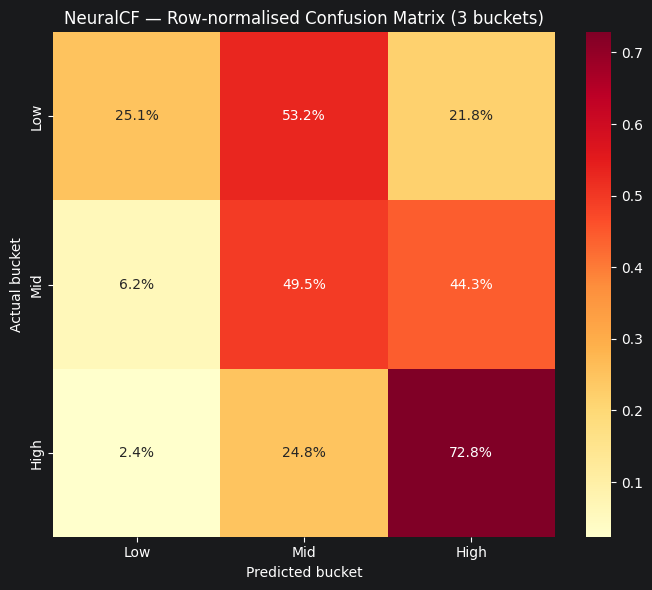

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def bucket(ratings):
    return pd.cut(
        ratings,
        bins=[0, 2.5, 3.5, 5.01],
        labels=["Low (≤2.5)", "Mid (3–3.5)", "High (≥4)"]
    )

true_buckets = bucket(best_ncf_true)
pred_buckets = bucket(np.clip(best_ncf_preds, 0.5, 5.0))

cm3 = confusion_matrix(true_buckets, pred_buckets,
                        labels=["Low (≤2.5)", "Mid (3–3.5)", "High (≥4)"])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm3 / cm3.sum(axis=1, keepdims=True),  # row-normalise → recall per class
    annot=True, fmt=".1%", cmap="YlOrRd",
    xticklabels=["Low", "Mid", "High"],
    yticklabels=["Low", "Mid", "High"], ax=ax
)
ax.set_xlabel("Predicted bucket")
ax.set_ylabel("Actual bucket")
ax.set_title("NeuralCF — Row-normalised Confusion Matrix (3 buckets)")
plt.tight_layout()
plt.show()